# Machine Learning Model Training & Evaluation

## Objective

The objective of this notebook is to train, compare, and evaluate multiple machine learning regression models for predicting the burned forest area.

This notebook includes:

- Loading the engineered dataset
- Feature selection
- Train-test split
- Data preprocessing
- Model training
- Cross-validation
- Hyperparameter tuning
- Model evaluation
- Model comparison
- Saving the best-performing model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


### Load Engineered Dataset

In [2]:
df = pd.read_csv("../../dataset/forestfires_engineered.csv")

print(df.shape)

df.head()

(513, 26)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,...,dryness_index,wind_effect,fuel_moisture_deficit,month_num,month_sin,month_cos,day_num,day_sin,day_cos,location_cluster
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,...,0.157692,54.94,0.503846,3,1.000000,6.123234e-17,5,-9.749279e-01,-0.222521,2
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,...,0.529412,16.20,1.041176,10,-0.866025,5.000000e-01,2,9.749279e-01,-0.222521,2
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,...,0.429412,18.98,1.285294,10,-0.866025,5.000000e-01,6,-7.818315e-01,0.623490,2
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,...,0.084694,33.20,0.339796,3,1.000000,6.123234e-17,5,-9.749279e-01,-0.222521,0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,...,0.114000,20.52,0.513000,3,1.000000,6.123234e-17,7,-2.449294e-16,1.000000,0


### Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X                      513 non-null    int64  
 1   Y                      513 non-null    int64  
 2   month                  513 non-null    str    
 3   day                    513 non-null    str    
 4   FFMC                   513 non-null    float64
 5   DMC                    513 non-null    float64
 6   DC                     513 non-null    float64
 7   ISI                    513 non-null    float64
 8   temp                   513 non-null    float64
 9   RH                     513 non-null    int64  
 10  wind                   513 non-null    float64
 11  rain                   513 non-null    float64
 12  area                   513 non-null    float64
 13  season                 513 non-null    str    
 14  rain_present           513 non-null    int64  
 15  fire_weather_scor

In [4]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,dryness_index,wind_effect,fuel_moisture_deficit,month_num,month_sin,month_cos,day_num,day_sin,day_cos,location_cluster
count,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,...,513.000000,513.000000,513.000000,513.000000,513.000000,5.130000e+02,513.000000,5.130000e+02,513.000000,513.000000
mean,4.678363,4.300195,90.637427,110.989279,549.155166,9.023587,18.887524,44.348928,4.010526,0.021832,...,0.494685,73.370195,2.722302,7.485380,-0.543845,-2.180249e-01,4.251462,-5.849145e-02,0.109638,1.814815
std,2.320059,1.230925,5.540920,64.191013,247.724594,4.575543,5.828128,16.358803,1.796613,0.297107,...,0.274664,36.137404,1.759024,2.275095,0.701591,4.071255e-01,2.075038,7.075839e-01,0.696998,1.049002
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,...,0.036667,4.140000,0.010891,1.000000,-1.000000,-1.000000e+00,1.000000,-9.749279e-01,-0.900969,0.000000
25%,3.000000,4.000000,90.200000,68.600000,440.900000,6.400000,15.500000,33.000000,2.700000,0.000000,...,0.293056,46.080000,1.410000,7.000000,-1.000000,-5.000000e-01,2.000000,-7.818315e-01,-0.222521,1.000000
50%,4.000000,4.000000,91.600000,108.300000,664.500000,8.400000,19.300000,42.000000,4.000000,0.000000,...,0.443182,69.600000,2.484783,8.000000,-0.866025,-1.836970e-16,5.000000,-2.449294e-16,-0.222521,2.000000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,11.000000,22.800000,53.000000,4.900000,0.000000,...,0.632500,97.020000,3.667568,9.000000,-0.500000,-1.836970e-16,6.000000,7.818315e-01,0.623490,3.000000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,...,1.540000,213.380000,10.885000,12.000000,1.000000,1.000000e+00,7.000000,9.749279e-01,1.000000,3.000000


### Prepare Features and Target

In [7]:
# Create log-transformed target
df["target"] = np.log1p(df["area"])

X = df.drop(
    columns=[
        "area",
        "target",
        "month",
        "day",
        "season"
    ]
)

y = df["target"]

print("Feature Matrix:", X.shape)
print("Target:", y.shape)

Feature Matrix: (513, 22)
Target: (513,)


### Check Feature List

In [10]:
print(X.shape)

print(X.columns.tolist())

(513, 22)
['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'rain_present', 'fire_weather_score', 'dryness_index', 'wind_effect', 'fuel_moisture_deficit', 'month_num', 'month_sin', 'month_cos', 'day_num', 'day_sin', 'day_cos', 'location_cluster']


# Feature Importance Analysis

Before training multiple machine learning models, feature importance analysis is performed to understand which variables contribute the most to predicting burned area.

A Random Forest Regressor is used because it naturally estimates the importance of each feature based on its contribution to reducing prediction error across many decision trees.

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
6,temp,0.108606
13,wind_effect,0.107632
14,fuel_moisture_deficit,0.096383
12,dryness_index,0.075423
7,RH,0.063731
0,X,0.060135
11,fire_weather_score,0.055145
3,DMC,0.053623
4,DC,0.051863
1,Y,0.051646


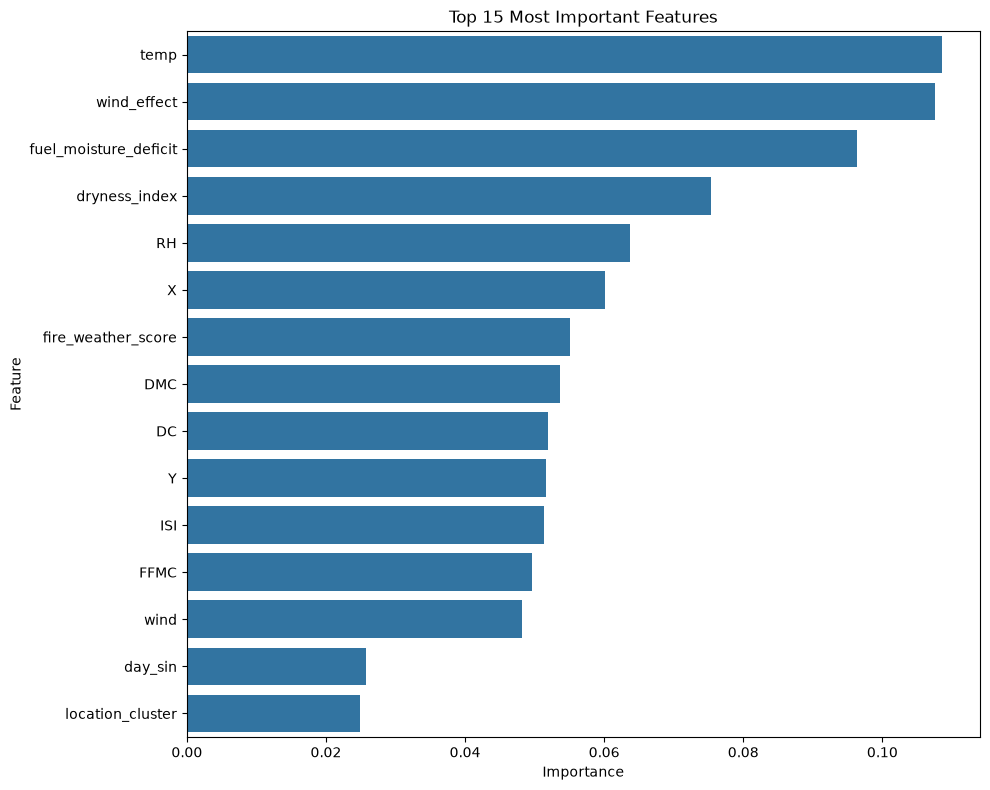

In [12]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.tight_layout()

plt.show()